# Propaganda / BPC Analysis

In [1]:
import os
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from google.colab import drive

## Load & merge per-model entropy results

In [2]:
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/entropy_results'

Mounted at /content/drive


In [3]:
dataframes = []
metrics = ['bpc', 'total_bits', 'valid_chars']

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        temp_df = pd.read_csv(file_path, low_memory=False)

        name_without_ext = os.path.splitext(filename)[0]

        cols_to_drop = [c for c in ['model_name'] if c in temp_df.columns]
        temp_df = temp_df.drop(columns=cols_to_drop)

        rename_dict = {m: f"{m}_{name_without_ext}" for m in metrics if m in temp_df.columns}
        temp_df = temp_df.rename(columns=rename_dict)

        dataframes.append(temp_df)

common_cols = list(set.intersection(*[set(df.columns) for df in dataframes]))
merge_keys = [c for c in common_cols if not any(c.startswith(f"{m}_") for m in metrics)]

df = reduce(lambda left, right: pd.merge(left, right, on=merge_keys, how='outer'), dataframes)

rename_dict = {}
for col in df.columns:
    if 'Unnamed: 1' in str(col) or str(col).strip() == '':
        rename_dict[col] = 'propaganda_technique'
df.rename(columns=rename_dict, inplace=True)

print(df.head())

   Unnamed: 0.1                                              Title  \
0            84  На Львівщині повертаються до графіків відключе...   
1            84  На Львівщині повертаються до графіків відключе...   
2            84  На Львівщині повертаються до графіків відключе...   
3            66  Total number of Russian troops in Belarus is n...   
4            66  Total number of Russian troops in Belarus is n...   

                                                Text Date  \
0  Про це повідомляє Львівобленерго, передає "Есп...    -   
1  Про це повідомляє Львівобленерго, передає "Есп...    -   
2  Про це повідомляє Львівобленерго, передає "Есп...    -   
3  He told about this on Espreso.  "Looking at la...    -   
4  He told about this on Espreso.  "Looking at la...    -   

                        Link     BERT label SVM label  Number quotes  \
0   https://zahid.espreso.tv  No propaganda       [0]       0.006098   
1   https://zahid.espreso.tv  No propaganda       [0]       0.006098

In [4]:
print(df.shape)

(104942, 216)


## Propaganda label & dataset name assignment

In [5]:
def assign_propaganda_label(row):
    path = str(row.get('source_file', '')).lower()

    if 'fake' in path:
        return 1
    if 'real' in path:
        return 0

    bert_val = str(row.get('BERT label', ''))
    if bert_val == 'Propaganda':
        return 1
    if bert_val == 'No propaganda':
        return 0

    if 'messages_combined' in path:
        if pd.notna(row.get('narrative_id')) or pd.notna(row.get('sub_narrative_id')):
            return 1
        bin_val = row.get('binary_label')
        if pd.notna(bin_val):
            return 1 if bool(bin_val) else 0
        return np.nan

    if 'tweets' in path:
        strat_val = str(row.get('strategy', '')).strip().lower()
        if strat_val == 'general discourse':
            return 0
        elif pd.notna(row.get('strategy')) and strat_val != 'nan':
            return 1
        else:
            return np.nan

    return np.nan

df['is_propaganda'] = df.apply(assign_propaganda_label, axis=1)

In [6]:
def get_dataset_name(path):
    path = str(path).lower()
    if 'messages_combined' in path:
        return 'dataset_telegram'
    elif 'tweets' in path:
        return 'dataset_tweets'
    elif 'labeled' in path:
        return 'dataset_labeled_news'
    else:
        return 'dataset_scraped_news'

df['dataset_name'] = df['source_file'].apply(get_dataset_name)

cols = ['dataset_name'] + [col for col in df.columns if col != 'dataset_name']
df = df[cols]

print(df['dataset_name'].value_counts())

dataset_name
dataset_telegram        55186
dataset_scraped_news    37261
dataset_tweets           9736
dataset_labeled_news     2759
Name: count, dtype: int64


In [7]:
for dataset, group_df in df.groupby('dataset_name'):
    active_cols = group_df.dropna(how='all', axis=1).columns.tolist()
    print(f"Dataset: {dataset}")
    print(f"  Rows: {len(group_df)}")
    print(f"  Columns ({len(active_cols)}): {active_cols}\n" + "-" * 60)

Dataset: dataset_labeled_news
  Rows: 2759
  Columns (187): ['dataset_name', 'Unnamed: 0.1', 'Title', 'Text', 'Date', 'Link', 'BERT label', 'SVM label', 'Number quotes', 'Mentionning statistics', 'Using but', 'Number of Adjectives', 'Number of Adverbs', 'Number of negations', 'Mentionning surveys', 'Average sentence length', 'Number of proper nouns', 'Mentionning reports', 'Number of conjunctions', 'Number of comparatives (better than)', 'Number of superlatives (the best)', 'Number of questions', 'Number of personal pronouns 1 person singular', 'Number of personal pronouns', 'Mentionning money', 'Number of modal verbs', 'Number of stative verbs', 'Emotion of fear', 'Emotion of surprise', 'Emotion of anger', 'Emotion of awaiting', 'Emotion of disgust', 'Emotion of happiness', 'Negative sentiment', 'Positive sentiment', 'Emotion of sadness', 'Emotion of trust', 'Number of abstract nouns', 'Number of assertion words', 'Number of discourse markers', 'Number of claims', 'Number of high moda

## Document-level aggregation & statistical testing

Raw rows in `df` are per-sentence entropy measurements. Averaging per-row BPC ratios is not statistically correct, so sentence-level rows are first grouped back into whole documents (by `original_text`), bits and characters are summed per document, and a true document-level BPC is recomputed as `sum(total_bits) / sum(valid_chars)`. All descriptive stats, tests, and plots below operate on that document-level table.

In [8]:
OUT = Path("outputs")
FIG_DIR = OUT / "figures"

MODELS = [
    "mlx-community_Qwen2.5-7B-Instruct-4bit",
    "google_gemma-3-1b-pt",
    "meta-llama_Llama-3.2-3B",
    "gemma-3-12b-4bit",
    "lapa-12b-pt-4bit",
]

PRIMARY_MODEL = "mlx-community_Qwen2.5-7B-Instruct-4bit"
PRIMARY_COL = f"bpc_entropy_{PRIMARY_MODEL}"

# A document is identified by original_text alone; dataset_name /
# detected_lang / is_propaganda are constant per document and carried
# along via first() rather than folded into the group key.
DOC_KEY_COL = "original_text"
META_COLS = ["dataset_name", "detected_lang", "is_propaganda"]

MIN_GROUP_N = 30  # minimum documents per group to trust a stat/test/plot
sns.set_theme(style="whitegrid", context="talk")

In [9]:
def aggregate_to_document_level(df_input: pd.DataFrame) -> pd.DataFrame:
    """Group sentence-level rows by original_text, sum bits/chars per
    model, and recompute one true document-level BPC per model."""
    bits_cols = {m: f"total_bits_entropy_{m}" for m in MODELS}
    chars_cols = {m: f"valid_chars_entropy_{m}" for m in MODELS}

    sum_cols = [c for c in list(bits_cols.values()) + list(chars_cols.values())
                if c in df_input.columns]
    missing = [c for c in list(bits_cols.values()) + list(chars_cols.values())
               if c not in df_input.columns]
    if missing:
        print(f"[WARN] missing columns, skipped in aggregation: {missing}")

    meta_cols_present = [c for c in META_COLS if c in df_input.columns]

    n_rows_before = len(df_input)
    n_docs_before = df_input[DOC_KEY_COL].nunique()
    print(f"[aggregate] {n_rows_before:,} sentence-level rows -> "
          f"{n_docs_before:,} unique documents (by {DOC_KEY_COL})")

    grouped = df_input.groupby(DOC_KEY_COL, dropna=False)

    doc_sums = grouped[sum_cols].sum(min_count=1)
    doc_meta = grouped[meta_cols_present].first()
    n_sentences = grouped.size().rename("n_sentences")

    doc = doc_meta.join(doc_sums).join(n_sentences).reset_index()

    for m in MODELS:
        bcol, ccol = bits_cols[m], chars_cols[m]
        out_col = f"bpc_entropy_{m}"
        if bcol in doc.columns and ccol in doc.columns:
            doc[out_col] = np.where(doc[ccol] > 0, doc[bcol] / doc[ccol], np.nan)
        else:
            doc[out_col] = np.nan

    print(f"[aggregate] produced {len(doc):,} document-level rows "
          f"with recomputed bpc_entropy_* columns")
    return doc

In [10]:
def describe_group(s: pd.Series) -> dict:
    s = s.dropna()
    if len(s) == 0:
        return dict(n=0, mean=None, median=None, std=None, q25=None, q75=None)
    return dict(n=len(s), mean=s.mean(), median=s.median(), std=s.std(),
                q25=s.quantile(0.25), q75=s.quantile(0.75))

def build_descriptive_table(df_docs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, lang, label), g in df_docs.groupby(["dataset_name", "detected_lang", "is_propaganda"]):
        for model in MODELS:
            col = f"bpc_entropy_{model}"
            if col not in g.columns:
                continue
            stats = describe_group(g[col])
            rows.append({"dataset_name": dataset, "detected_lang": lang,
                         "is_propaganda": label, "model": model, **stats})
    return pd.DataFrame(rows)

In [11]:
def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def run_tests(df_docs: pd.DataFrame) -> pd.DataFrame:
    results = []
    for (dataset, lang), g in df_docs.groupby(["dataset_name", "detected_lang"]):
        prop = g[g["is_propaganda"] == 1]
        nonprop = g[g["is_propaganda"] == 0]
        if len(prop) < MIN_GROUP_N or len(nonprop) < MIN_GROUP_N:
            continue

        for model in MODELS:
            col = f"bpc_entropy_{model}"
            if col not in prop.columns or col not in nonprop.columns:
                continue

            a, b = prop[col].dropna(), nonprop[col].dropna()
            if len(a) < MIN_GROUP_N or len(b) < MIN_GROUP_N:
                continue

            u_stat, p_val = mannwhitneyu(a, b, alternative="two-sided")
            effect = rank_biserial(u_stat, len(a), len(b))

            results.append({
                "dataset_name": dataset, "detected_lang": lang, "model": model,
                "n_propaganda": len(a), "n_nonpropaganda": len(b),
                "mean_bpc_propaganda": a.mean(), "mean_bpc_nonpropaganda": b.mean(),
                "diff_mean": a.mean() - b.mean(), "u_stat": u_stat, "p_value": p_val,
                "rank_biserial_effect": effect,
            })

    res = pd.DataFrame(results)
    if len(res) == 0:
        print("[WARN] No group had enough data for testing -- check MIN_GROUP_N.")
        return res

    reject, p_adj, _, _ = multipletests(res["p_value"], alpha=0.05, method="fdr_bh")
    res["p_value_fdr"] = p_adj
    res["significant_fdr_0.05"] = reject
    return res.sort_values("p_value_fdr")

In [12]:
def plot_language(df_lang: pd.DataFrame, lang: str):
    lang_dir = FIG_DIR / lang
    lang_dir.mkdir(parents=True, exist_ok=True)

    df_lang = df_lang.copy()
    df_lang["propaganda_label"] = df_lang["is_propaganda"].map({0: "Non-propaganda", 1: "Propaganda"})

    # A) boxplot for the primary model
    if PRIMARY_COL in df_lang.columns:
        plt.figure(figsize=(11, 6))
        sns.boxplot(data=df_lang, x="dataset_name", y=PRIMARY_COL, hue="propaganda_label", showfliers=False)
        plt.title(f"Document-level BPC Entropy ({PRIMARY_MODEL}) by Dataset & Label -- lang: {lang}")
        plt.ylabel("Bits per character (whole document)")
        plt.xlabel("")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig(lang_dir / "A_boxplot_primary_model.png", dpi=150)
        plt.close()

    # B) small multiples across all models
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    axes = axes.flatten()
    for i, model in enumerate(MODELS):
        col = f"bpc_entropy_{model}"
        if col not in df_lang.columns or df_lang[col].notna().sum() < MIN_GROUP_N:
            axes[i].set_visible(False)
            continue
        sns.boxplot(data=df_lang, x="dataset_name", y=col, hue="propaganda_label",
                    showfliers=False, ax=axes[i], legend=(i == 0))
        axes[i].set_title(model.split("_")[-1] if "_" in model else model, fontsize=13)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("BPC")
        axes[i].tick_params(axis="x", rotation=30)
    axes[-1].set_visible(False)
    fig.suptitle(f"Document-level BPC Entropy across all 5 models -- lang: {lang}", fontsize=16)
    plt.tight_layout()
    plt.savefig(lang_dir / "B_all_models_grid.png", dpi=150)
    plt.close()

    # C) pooled KDE overlay
    if PRIMARY_COL in df_lang.columns:
        plt.figure(figsize=(9, 6))
        sns.kdeplot(data=df_lang, x=PRIMARY_COL, hue="propaganda_label", common_norm=False, fill=True, alpha=0.35)
        plt.title(f"Document-level BPC distribution (Qwen), pooled across datasets -- lang: {lang}")
        plt.xlabel("Bits per character (whole document)")
        plt.tight_layout()
        plt.savefig(lang_dir / "C_kde_pooled.png", dpi=150)
        plt.close()

    # D) mean BPC heatmap
    if PRIMARY_COL in df_lang.columns:
        pivot = df_lang.pivot_table(index="dataset_name", columns="propaganda_label", values=PRIMARY_COL, aggfunc="mean")
        if pivot.shape[0] > 0:
            plt.figure(figsize=(6, 4 + 0.3 * pivot.shape[0]))
            sns.heatmap(pivot, annot=True, fmt=".3f", cmap="rocket_r")
            plt.title(f"Mean document-level BPC (Qwen) -- lang: {lang}")
            plt.tight_layout()
            plt.savefig(lang_dir / "D_heatmap_mean_bpc.png", dpi=150)
            plt.close()

    print(f"[{lang}] figures saved -> {lang_dir}")

In [13]:
def macro_direction_table(df_docs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, lang), g in df_docs.groupby(["dataset_name", "detected_lang"]):
        prop = g[g["is_propaganda"] == 1]
        nonprop = g[g["is_propaganda"] == 0]
        if len(prop) < MIN_GROUP_N or len(nonprop) < MIN_GROUP_N:
            continue
        for model in MODELS:
            col = f"bpc_entropy_{model}"
            if col not in prop.columns or col not in nonprop.columns:
                continue
            a, b = prop[col].dropna(), nonprop[col].dropna()
            if len(a) < MIN_GROUP_N or len(b) < MIN_GROUP_N:
                continue
            diff = a.mean() - b.mean()
            rows.append({"dataset_name": dataset, "detected_lang": lang, "model": model,
                         "diff_mean_bpc": diff,
                         "direction": "propaganda higher" if diff > 0 else "propaganda lower"})
    return pd.DataFrame(rows)

def consistency_summary(direction_df: pd.DataFrame) -> pd.DataFrame:
    summary = (direction_df.groupby("model")["direction"]
               .value_counts(normalize=True).unstack(fill_value=0).round(3))
    summary["n_groups"] = direction_df.groupby("model").size()
    return summary

In [14]:
def model_agreement_heatmap(df_docs: pd.DataFrame, lang: str):
    cols = [f"bpc_entropy_{m}" for m in MODELS if f"bpc_entropy_{m}" in df_docs.columns]
    sub = df_docs[cols].dropna()
    if len(sub) < MIN_GROUP_N:
        return
    corr = sub.corr(method="spearman")
    short_labels = [c.replace("bpc_entropy_", "") for c in corr.columns]
    corr.columns = short_labels
    corr.index = short_labels

    plt.figure(figsize=(8, 6.5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
    plt.title(f"Cross-model Spearman agreement on document-level BPC -- lang: {lang}\n(n={len(sub):,} docs)")
    plt.tight_layout()
    lang_dir = FIG_DIR / lang
    lang_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(lang_dir / "E_model_agreement_heatmap.png", dpi=150)
    plt.close()
    print(f"[{lang}] model agreement heatmap saved")

In [15]:
def main(df_input: pd.DataFrame):
    OUT.mkdir(exist_ok=True)
    FIG_DIR.mkdir(exist_ok=True)

    # Step 1: aggregate sentence-level rows to one row per document
    df_docs = aggregate_to_document_level(df_input)
    df_docs.to_csv(OUT / "document_level_bpc.csv", index=False)

    # Step 2: descriptive stats on document-level BPC
    desc = build_descriptive_table(df_docs)
    desc.to_csv(OUT / "descriptive_stats_long.csv", index=False)

    qwen = desc[desc["model"] == PRIMARY_MODEL]
    if len(qwen) > 0:
        pivot = qwen.pivot_table(index=["dataset_name", "detected_lang"], columns="is_propaganda",
                                  values=["mean", "median", "n"])
        pivot.to_csv(OUT / "descriptive_stats_qwen_wide.csv")

    # Step 3: significance testing on document-level BPC
    results = run_tests(df_docs)
    results.to_csv(OUT / "statistical_tests.csv", index=False)
    if len(results) > 0:
        print(f"{results['significant_fdr_0.05'].sum()} / {len(results)} tests significant after FDR correction")

    # Step 4: per-language visualizations
    lang_counts = df_docs["detected_lang"].value_counts()
    langs_to_plot = lang_counts[lang_counts >= MIN_GROUP_N].index.tolist()
    for lang in langs_to_plot:
        plot_language(df_docs[df_docs["detected_lang"] == lang], lang)

    # Step 5: macro trends & cross-model agreement
    direction_df = macro_direction_table(df_docs)
    if len(direction_df) > 0:
        direction_df.to_csv(OUT / "macro_direction_by_group.csv", index=False)
        consistency = consistency_summary(direction_df)
        consistency.to_csv(OUT / "macro_direction_consistency_by_model.csv")

    for lang in langs_to_plot:
        model_agreement_heatmap(df_docs[df_docs["detected_lang"] == lang], lang)

In [16]:
main(df)

[aggregate] 104,942 sentence-level rows -> 54,997 unique documents (by original_text)
[aggregate] produced 54,997 document-level rows with recomputed bpc_entropy_* columns
15 / 20 tests significant after FDR correction
[uk] figures saved -> outputs/figures/uk
[en] figures saved -> outputs/figures/en
[uk] model agreement heatmap saved
[en] model agreement heatmap saved


## Telegram narrative / sub-narrative / strategy breakdowns

Same document-level aggregation as above (sum bits/chars per `original_text`, recompute BPC), scoped to the Telegram dataset and broken down by narrative, sub-narrative, and strategy.

In [17]:
# --- Shared document-level BPC aggregation & plotting helpers ---
# Factored out of analyze_telegram_narratives_clean, plot_top_categorical_bpc,
# and plot_macro_intents, which all repeated the same "group sentence rows by
# original_text -> sum bits/chars -> recompute BPC -> boxplot by language"
# logic with small variations. The three call sites keep their own filtering
# rules (min-count-30 vs top-N vs macro-intent schema mapping); only the
# aggregation and plotting mechanics are shared.

def _aggregate_document_bpc(df_input: pd.DataFrame, bpc_col: str, dataset_filter: str,
                             category_source_col: str = None):
    """Collapse sentence-level rows (filtered to `dataset_filter`) into
    document-level rows keyed by `original_text`, summing bits/chars and
    recomputing BPC at the document level. Optionally carries through one
    extra categorical column (first non-null value per document).
    Returns (doc_df, bits_col, chars_col, n_sentence_rows). doc_df is empty
    if there's no data or the required bits/chars columns are missing."""
    df_sub = df_input[df_input['dataset_name'] == dataset_filter].copy()
    if df_sub.empty:
        return df_sub, None, None, 0

    model_name = bpc_col.replace("bpc_entropy_", "", 1)
    bits_col = f"total_bits_entropy_{model_name}"
    chars_col = f"valid_chars_entropy_{model_name}"
    if bits_col not in df_sub.columns or chars_col not in df_sub.columns:
        print(f"[WARN] missing {bits_col} or {chars_col} -- cannot compute document-level BPC")
        return pd.DataFrame(), bits_col, chars_col, len(df_sub)

    meta_cols = [c for c in ['dataset_name', 'detected_lang', 'is_propaganda']
                 if c in df_sub.columns]

    grouped = df_sub.groupby('original_text', dropna=False)
    doc_sums = grouped[[bits_col, chars_col]].sum(min_count=1)
    doc_meta = grouped[meta_cols].first()

    if category_source_col and category_source_col in df_sub.columns:
        doc_cat = grouped[category_source_col].apply(
            lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan
        ).rename(category_source_col)
        doc_meta = doc_meta.join(doc_cat)

    doc = doc_meta.join(doc_sums).reset_index()
    doc[bpc_col] = doc[bits_col] / doc[chars_col].where(doc[chars_col] > 0)
    return doc, bits_col, chars_col, len(df_sub)


def _boxplot_bpc_by_language(df_doc: pd.DataFrame, bpc_col: str, category_col: str,
                              langs, title_template: str, palette: str = 'coolwarm',
                              figsize=(14, 10)):
    """Draw one boxplot of document-level BPC by `category_col`, per language.
    `title_template` should contain a `{lang}` placeholder."""
    for lang in langs:
        df_lang = df_doc[df_doc['detected_lang'] == lang].copy()
        if df_lang.empty:
            continue

        medians = df_lang.groupby(category_col)[bpc_col].median().sort_values(ascending=False)
        order = medians.index.tolist()

        plt.figure(figsize=figsize)
        sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,
                    palette=palette, showfliers=False)
        plt.title(title_template.format(lang=lang.upper()), fontsize=16)
        plt.xlabel('Bits per Character (BPC, whole document)', fontsize=14)
        plt.ylabel('', fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.tight_layout()
        plt.show()


[telegram] 55,186 sentence-level rows -> 33,079 documents


/tmp/ipykernel_1088/345313299.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,


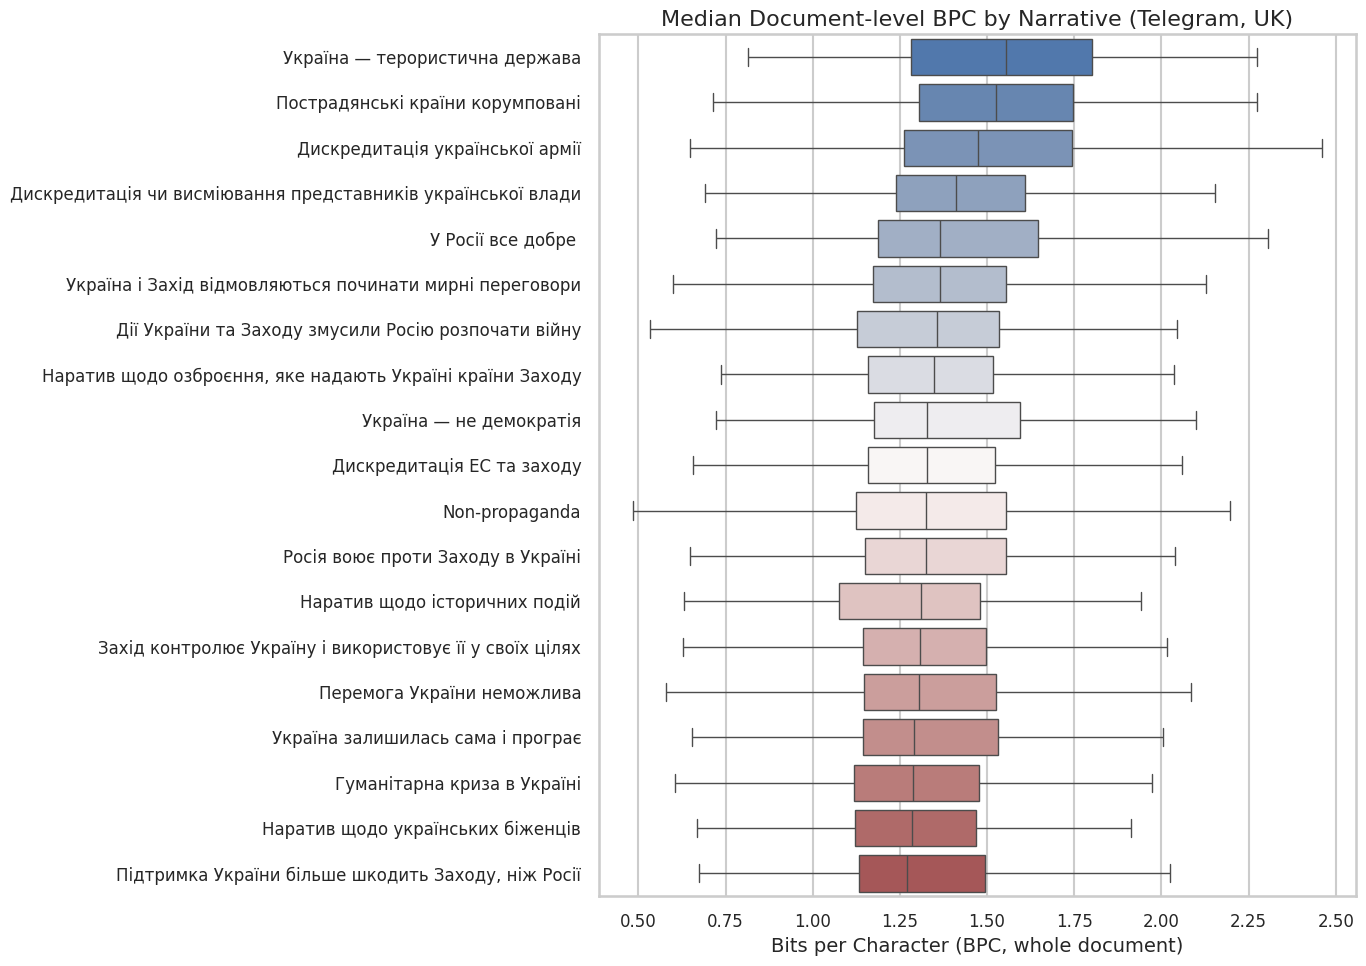

In [18]:
def analyze_telegram_narratives_clean(df_input: pd.DataFrame, bpc_col: str):
    """Boxplot of document-level BPC per Telegram narrative, by language."""
    doc, bits_col, chars_col, n_rows = _aggregate_document_bpc(
        df_input, bpc_col, dataset_filter='dataset_telegram', category_source_col='narrative'
    )
    if doc.empty:
        return

    print(f"[telegram] {n_rows:,} sentence-level rows -> {len(doc):,} documents")

    doc['plot_category'] = doc.apply(
        lambda row: 'Non-propaganda' if row['is_propaganda'] == 0 else str(row.get('narrative', 'Unknown')),
        axis=1
    )
    doc = doc[~doc['plot_category'].isin(['nan', 'None', 'Unknown'])]

    counts = doc['plot_category'].value_counts()
    valid_cats = counts[counts >= 30].index
    doc = doc[doc['plot_category'].isin(valid_cats)]

    _boxplot_bpc_by_language(
        doc, bpc_col, 'plot_category', langs=('uk', 'en'),
        title_template='Median Document-level BPC by Narrative (Telegram, {lang})',
        palette='vlag'
    )


analyze_telegram_narratives_clean(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit")


In [19]:
def plot_top_categorical_bpc(df_input: pd.DataFrame, bpc_col: str, col_name: str,
                              dataset_filter: str = 'dataset_telegram',
                              top_n: int = 15, langs=('uk', 'en'), label: str = None):
    """Boxplot of document-level BPC for the top-N most frequent values of
    `col_name` within `dataset_filter`, one plot per language. Unifies the
    previously duplicated per-column plotting functions. Note: the original
    'strategy' / 'propaganda_category' functions filtered on 'dataset_tweets'
    (not 'dataset_telegram', despite their naming) -- that original behavior
    is preserved here via dataset_filter, not silently changed."""
    df_sub = df_input[df_input['dataset_name'] == dataset_filter]
    if df_sub.empty or col_name not in df_sub.columns:
        print(f"[WARN] no data / missing column '{col_name}' -- skipping")
        return

    label = label or col_name.replace('_', ' ').title()

    doc, bits_col, chars_col, n_rows = _aggregate_document_bpc(
        df_input, bpc_col, dataset_filter=dataset_filter, category_source_col=col_name
    )
    if doc.empty:
        return

    print(f"[telegram {col_name}] {n_rows:,} sentence-level rows -> {len(doc):,} documents")

    doc['plot_category'] = doc.apply(
        lambda row: 'Non-propaganda' if row['is_propaganda'] == 0 else str(row.get(col_name, 'Unknown')),
        axis=1
    )
    doc = doc[~doc['plot_category'].isin(['nan', 'None', 'Unknown', 'General'])]

    for lang in langs:
        df_lang = doc[doc['detected_lang'] == lang].copy()
        if df_lang.empty:
            continue

        prop_only = df_lang[df_lang['plot_category'] != 'Non-propaganda']
        top_cats = prop_only['plot_category'].value_counts().head(top_n).index.tolist()

        valid_cats = ['Non-propaganda'] + top_cats
        df_plot = df_lang[df_lang['plot_category'].isin(valid_cats)]

        _boxplot_bpc_by_language(
            df_plot, bpc_col, 'plot_category', langs=(lang,),
            title_template=f'Median Document-level BPC by Top {top_n} {label} (Telegram, {{lang}})',
            palette='coolwarm'
        )


[telegram sub_narrative] 55,186 sentence-level rows -> 33,079 documents


/tmp/ipykernel_1088/345313299.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,


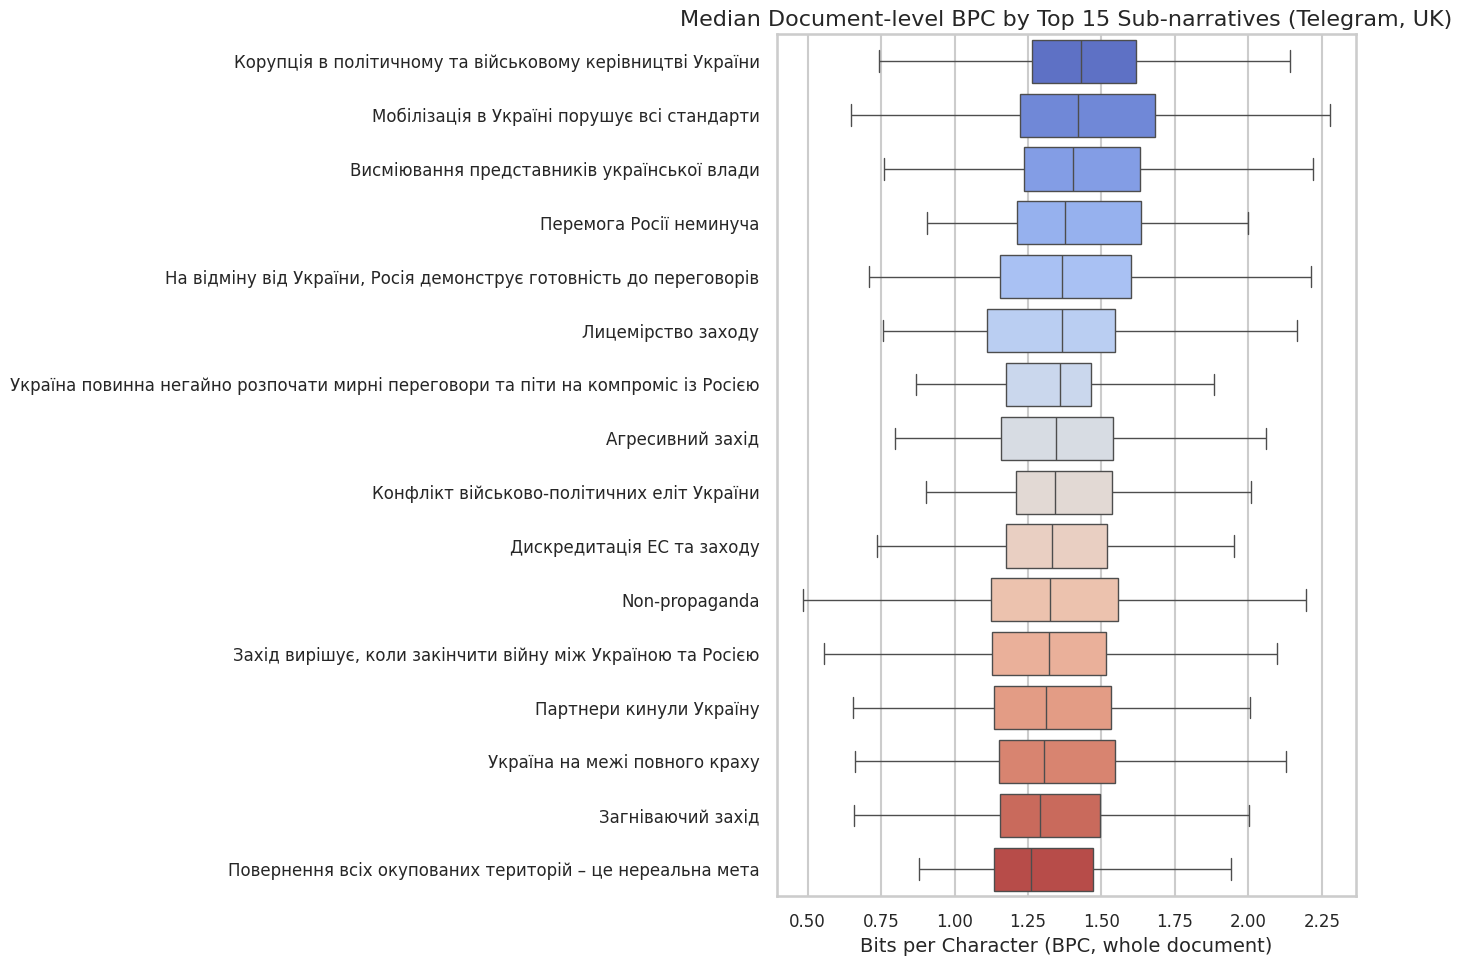

[telegram strategy] 9,736 sentence-level rows -> 9,404 documents


/tmp/ipykernel_1088/345313299.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,


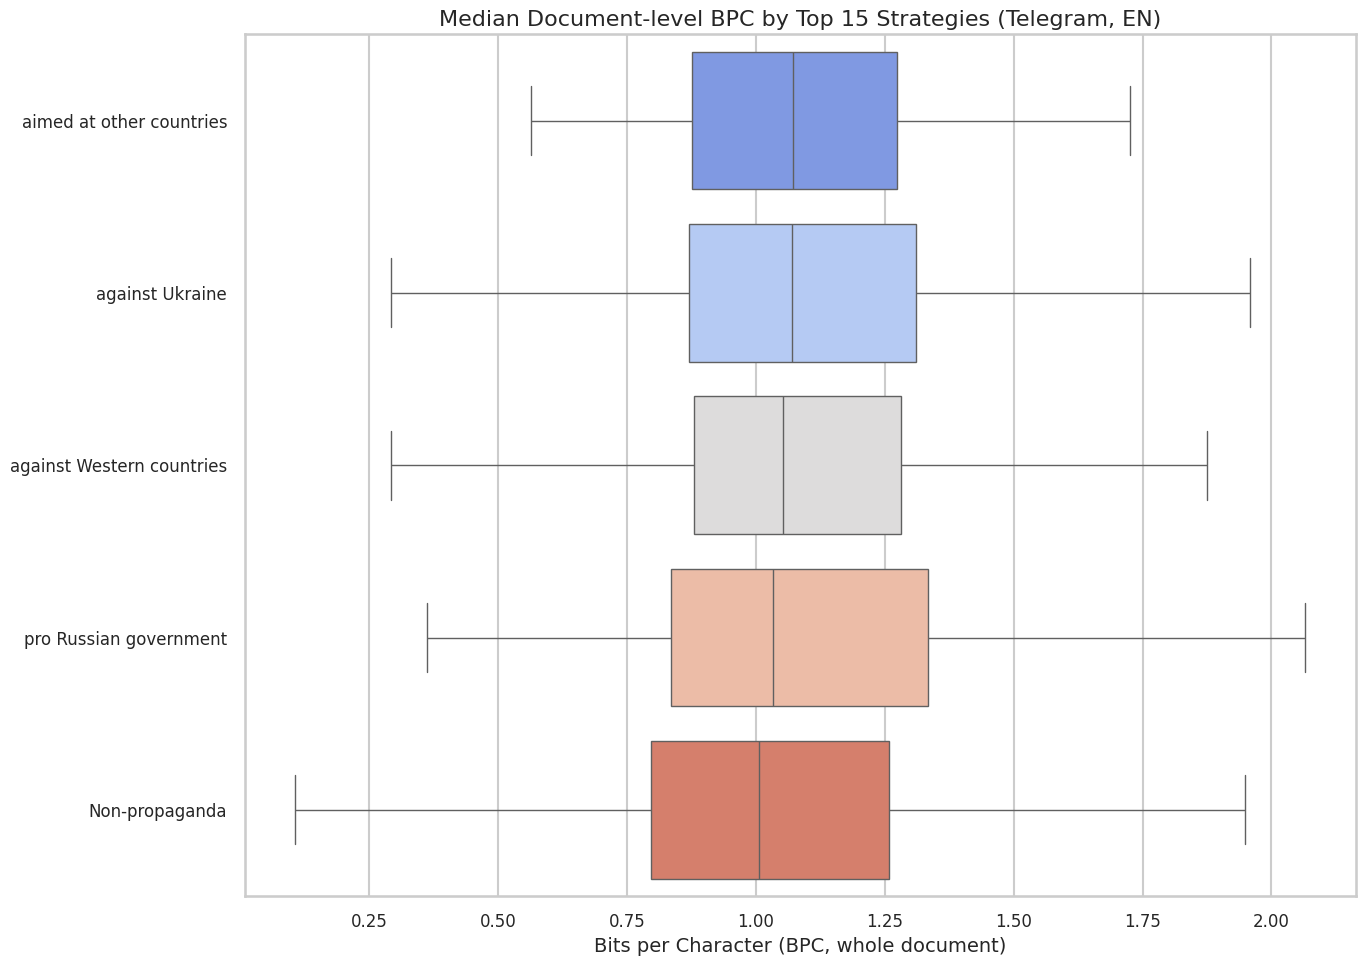

[telegram propaganda_category] 9,736 sentence-level rows -> 9,404 documents


/tmp/ipykernel_1088/345313299.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,


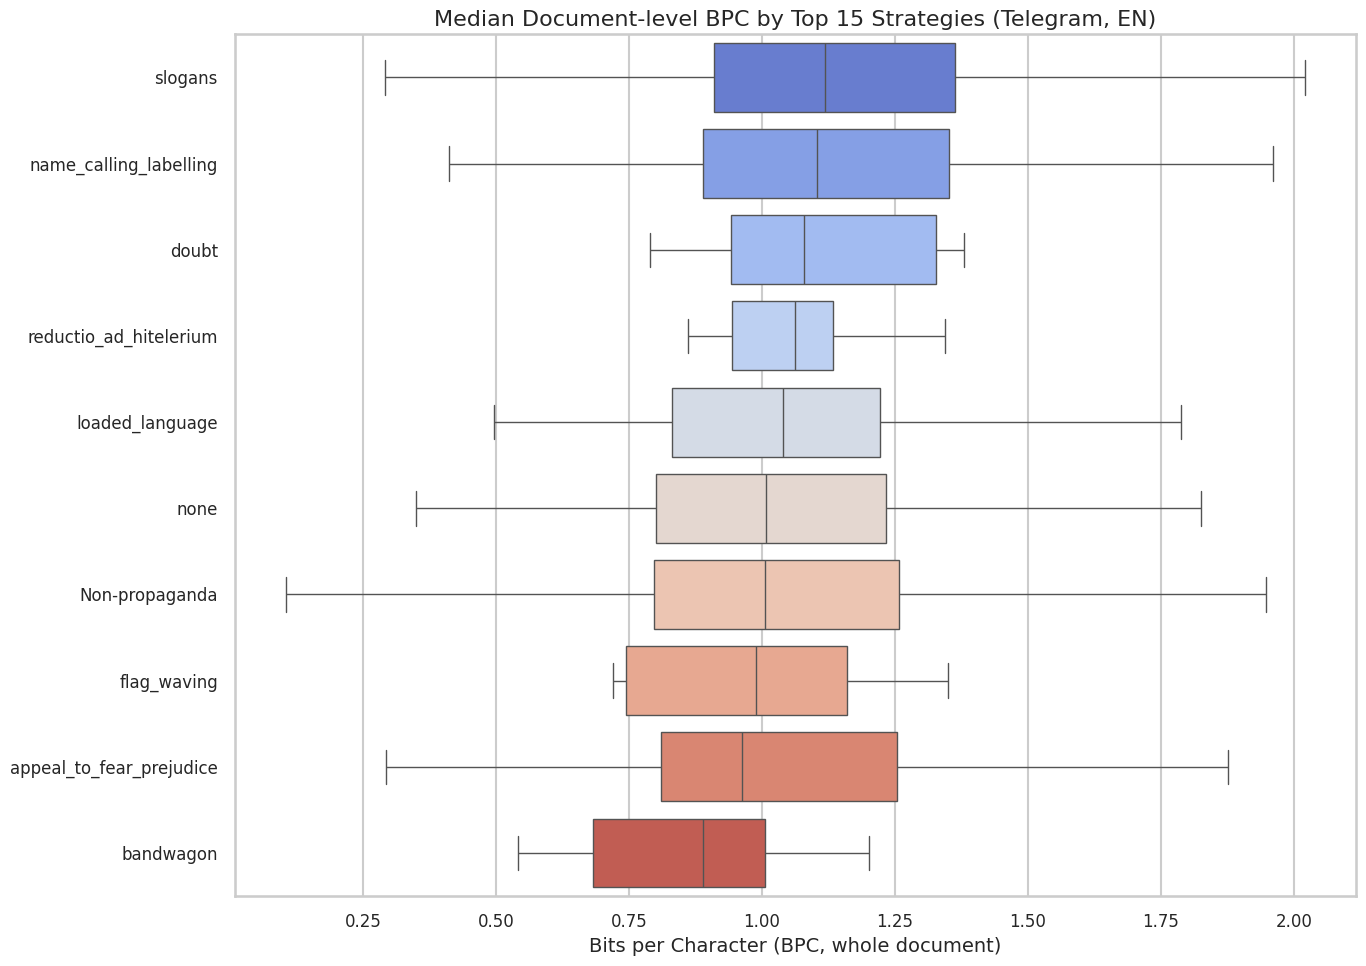

In [20]:
plot_top_categorical_bpc(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit",
                          col_name='sub_narrative', dataset_filter='dataset_telegram',
                          top_n=15, langs=('uk',), label='Sub-narratives')
plot_top_categorical_bpc(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit",
                          col_name='strategy', dataset_filter='dataset_tweets',
                          top_n=15, label='Strategies')
plot_top_categorical_bpc(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit",
                          col_name='propaganda_category', dataset_filter='dataset_tweets',
                          top_n=15, label='Strategies')

## Linguistic / keyword correlations (labeled news)

/tmp/ipykernel_1088/44481533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Correlation', y='Keyword', palette=colors)


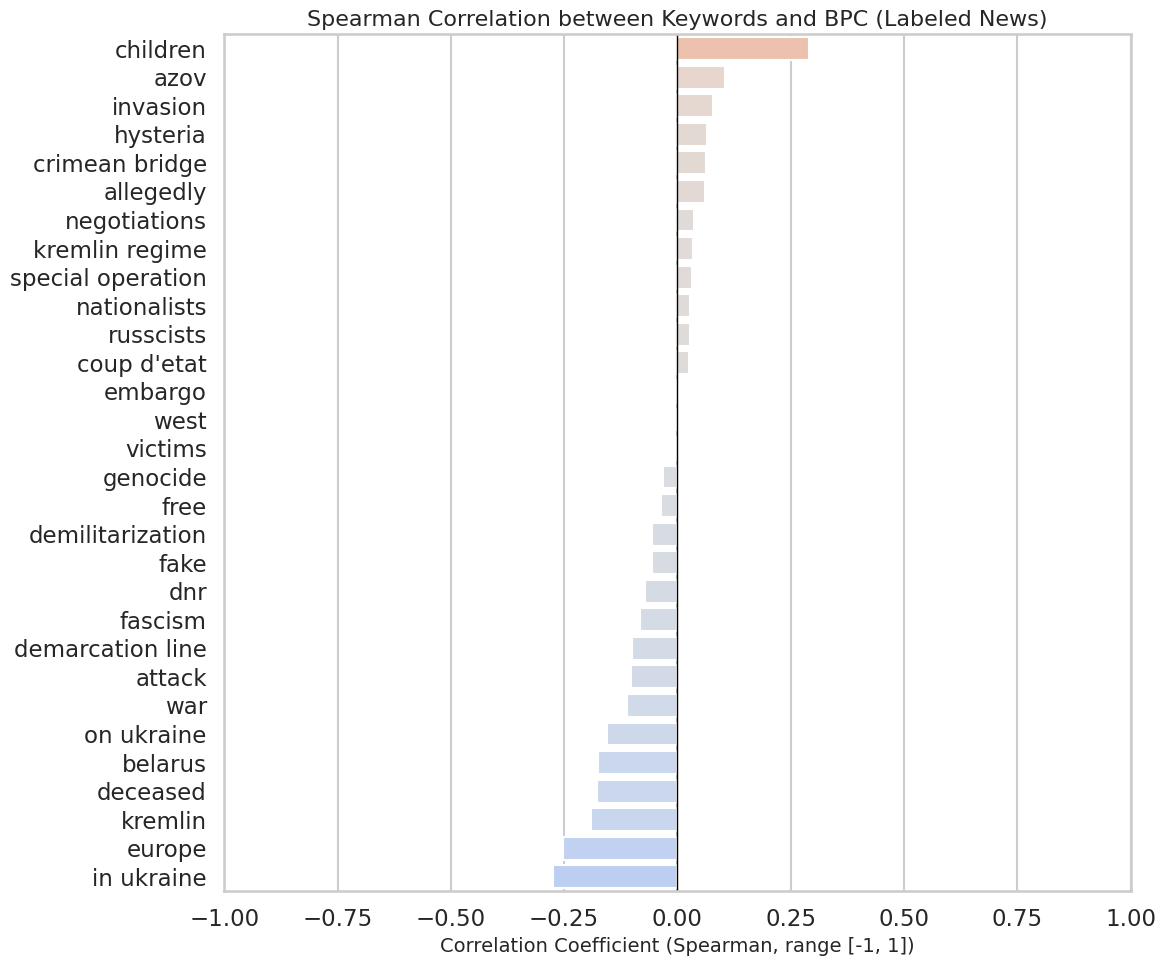

In [21]:
def plot_keyword_correlations_honest(df_input: pd.DataFrame, bpc_col: str, top_n: int = 15):
    df_news = df_input[df_input['dataset_name'] == 'dataset_labeled_news'].copy()
    if df_news.empty:
        return

    kw_cols = [c for c in df_news.columns if c.startswith('Keyword:')]

    correlations = []
    for col in kw_cols:
        if df_news[col].nunique() > 1:
            corr = df_news[bpc_col].corr(df_news[col], method='spearman')
            if pd.notna(corr):
                correlations.append({'Keyword': col.replace('Keyword:', '').strip(), 'Correlation': corr})

    df_corr = pd.DataFrame(correlations).sort_values(by='Correlation', ascending=False)

    top_positive = df_corr.head(top_n)
    top_negative = df_corr.tail(top_n)
    df_plot = pd.concat([top_positive, top_negative])

    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
    cmap = plt.get_cmap('coolwarm')
    colors = [cmap(norm(val)) for val in df_plot['Correlation']]

    plt.figure(figsize=(12, 10))
    sns.barplot(data=df_plot, x='Correlation', y='Keyword', palette=colors)
    plt.title('Spearman Correlation between Keywords and BPC (Labeled News)', fontsize=16)
    plt.xlabel('Correlation Coefficient (Spearman, range [-1, 1])', fontsize=14)
    plt.ylabel('')
    plt.xlim(-1.0, 1.0)
    plt.axvline(x=0, color='black', linewidth=1)
    plt.tight_layout()
    plt.show()


plot_keyword_correlations_honest(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit", top_n=15)

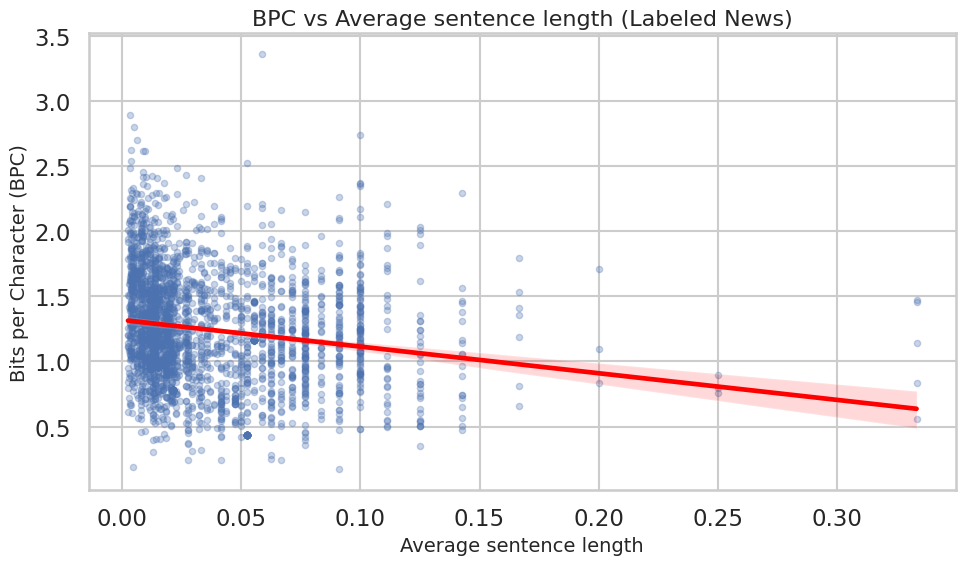

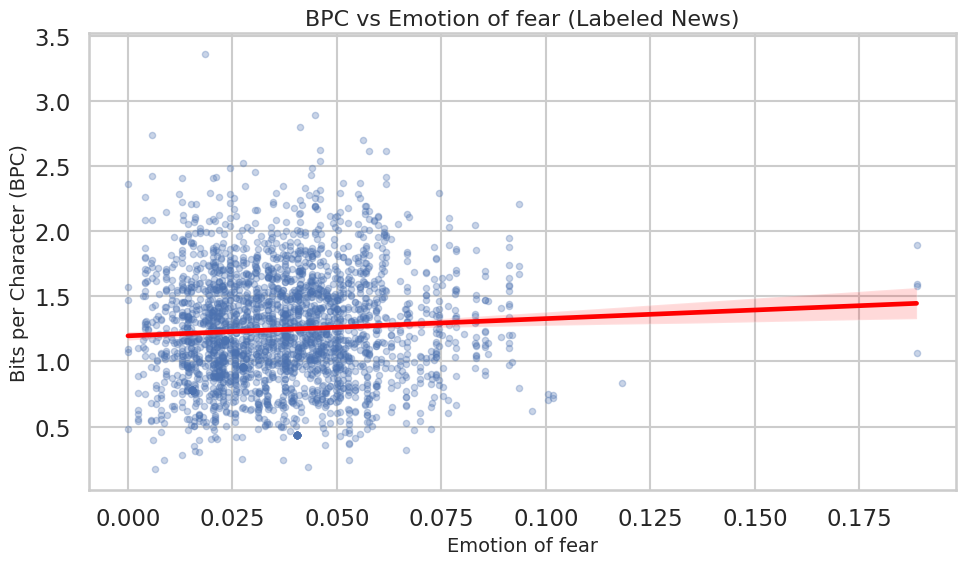

In [22]:
def plot_linguistic_scatter(df_input: pd.DataFrame, bpc_col: str, feature_col: str):
    df_news = df_input[df_input['dataset_name'] == 'dataset_labeled_news'].copy()
    if df_news.empty or feature_col not in df_news.columns:
        return

    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_news, x=feature_col, y=bpc_col,
                scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'red'})
    plt.title(f'BPC vs {feature_col} (Labeled News)', fontsize=16)
    plt.xlabel(feature_col, fontsize=14)
    plt.ylabel('Bits per Character (BPC)', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_linguistic_scatter(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit", "Average sentence length")
plot_linguistic_scatter(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit", "Emotion of fear")

In [23]:
print(df[df['dataset_name'] == 'dataset_tweets']['strategy'].unique())

['general discourse' 'against Ukraine' 'against Western countries'
 'pro Russian government' 'aimed at other countries']


## Macro-intent breakdowns (tweets)

In [24]:
SCHEMA_MAPPING = {
    "flag_waving": "Patriotic & Catchy Appeals",
    "slogans": "Patriotic & Catchy Appeals",
    "bandwagon": "Popularity Appeals",
    "whataboutism": "Deflections & Distractions",
    "repetition": "Deflections & Distractions",
    "causal_oversimplification": "Deflections & Distractions",
    "red_herring": "Deflections & Distractions",
    "loaded_language": "Emotional & Loaded Persuasion",
    "reductio_ad_hitelerium": "Emotional & Loaded Persuasion",
    "appeal_to_fear_prejudice": "Emotional & Loaded Persuasion",
    "name_calling_labelling": "Emotional & Loaded Persuasion",
    "exaggeration_minimization": "Emotional & Loaded Persuasion",
    "straw_man": "Argument Manipulations",
    "thought_terminating_cliches": "Argument Manipulations",
    "doubt": "Argument Manipulations",
    "black_and_white_fallacy": "Argument Manipulations",
    "none": "No Propaganda",
    "no_propaganda": "No Propaganda",
    # NOTE: keys are matched after .str.lower(), so the mapping must stay
    # lowercase -- the original 'plot_macro_intents' had a "Non-propaganda"
    # (capitalized) key here, which could never match and was dead code.
    "non-propaganda": "No Propaganda",
}

def plot_macro_intents(df_input: pd.DataFrame, bpc_col: str, source_col: str = 'strategy'):
    """Boxplot of document-level BPC by macro propaganda intent (Tweets).
    Unifies the two near-identical originals, which only differed in which
    column ('strategy' vs 'propaganda_category') fed the schema mapping."""
    df_sub = df_input[df_input['dataset_name'] == 'dataset_tweets']
    if df_sub.empty or source_col not in df_sub.columns:
        print(f"[WARN] no data / missing column '{source_col}' -- skipping")
        return

    doc, bits_col, chars_col, n_rows = _aggregate_document_bpc(
        df_input, bpc_col, dataset_filter='dataset_tweets', category_source_col=source_col
    )
    if doc.empty:
        return

    doc['macro_intent'] = doc[source_col].astype(str).str.lower().str.strip().map(SCHEMA_MAPPING)
    doc = doc[doc['macro_intent'].notna()]
    doc = doc[doc['macro_intent'] != 'No Propaganda']

    _boxplot_bpc_by_language(
        doc, bpc_col, 'macro_intent', langs=('uk', 'en'),
        title_template='Median Document-level BPC by Macro Intents (Tweets, {lang})',
        palette='coolwarm', figsize=(12, 6)
    )


/tmp/ipykernel_1088/345313299.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x=bpc_col, y=category_col, order=order,


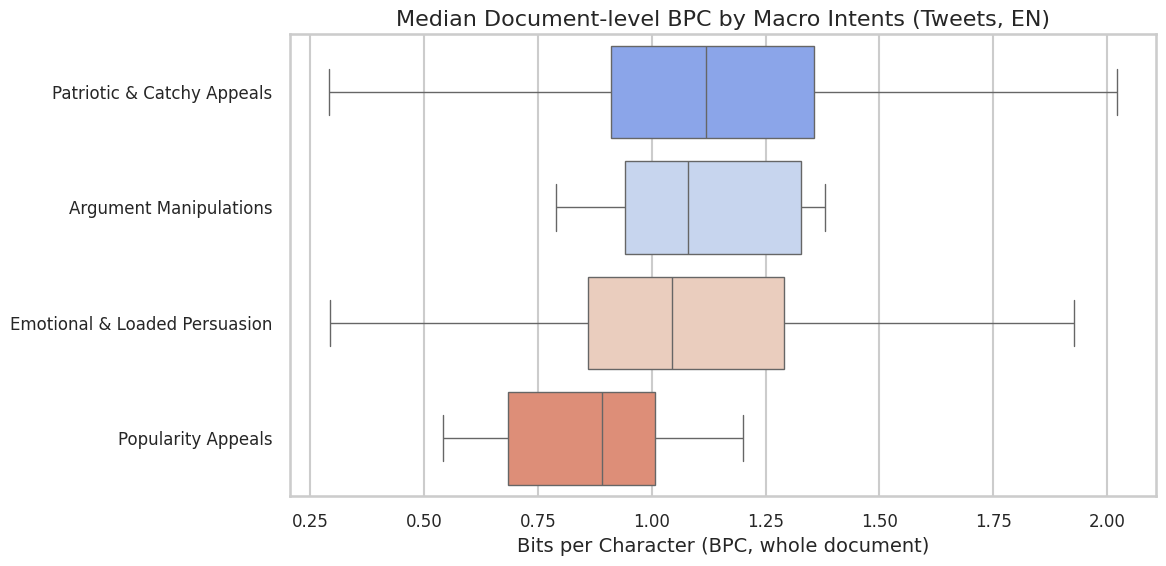

In [25]:
plot_macro_intents(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit", source_col='strategy')
plot_macro_intents(df, "bpc_entropy_mlx-community_Qwen2.5-7B-Instruct-4bit", source_col='propaganda_category')